## EDA( Exploratory Data Analysis )
 EDA is the process of examining, visualizing, and summarizing a dataset to understand its key characteristics before performing any modeling or advanced analysis.

#### IMPORT LIBRARIES

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### LOAD THE DATASET AND DISPLAY INFORMATION

In [83]:
df = pd.read_csv('C:/Users/divyanshu/OneDrive/Desktop/Projects/ImpactSense/impactsenseAI-Infosys-Intern-project/milestone_2/week_3/Day_13/preprocessed_earthquake_data.csv')

print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109848 entries, 0 to 109847
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   latitude          109848 non-null  float64
 1   longitude         109848 non-null  float64
 2   depth             109848 non-null  float64
 3   mag               109848 non-null  float64
 4   magType           109848 non-null  object 
 5   rms               109848 non-null  float64
 6   type              109848 non-null  object 
 7   status            109848 non-null  object 
 8   Year              109848 non-null  int64  
 9   Month             109848 non-null  int64  
 10  Day               109848 non-null  int64  
 11  Hour              109848 non-null  int64  
 12  Minute            109848 non-null  int64  
 13  Second            109848 non-null  int64  
 14  DayOfWeek         109848 non-null  int64  
 15  Mw                109715 non-null  float64
 16  damage

In [84]:
# Combine separate time components (Year, Month, Day, Hour, Minute, Second) into a single datetime column 

time_cols = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']
available_cols = [col for col in time_cols if col in df.columns]

if {'Year', 'Month', 'Day'}.issubset(df.columns):
    df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day']].astype(str).agg('-'.join, axis=1), errors='coerce')
elif 'Date' in df.columns:
    df['datetime'] = pd.to_datetime(df['Date'], errors='coerce')
else:
    raise ValueError("No recognizable time columns found.")

#### Task 1. Temporal Distribution Analysis
Analyze earthquake frequency and magnitude trends over time.


In [85]:
# Earthquake frequency by Year, Month, DayOfWeek
yearly_counts = df['Year'].value_counts().sort_index()
monthly_counts = df['Month'].value_counts()
weekday_counts = df['DayOfWeek'].value_counts()


# Mean magnitude and damage potential by temporal dimensions
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month_name()
df['DayOfWeek'] = df['datetime'].dt.day_name()

# Identify magnitude and damage columns
magnitude_col = next((col for col in df.columns if 'mag' in col.lower()), None)
damage_col = next((col for col in df.columns if 'damage_potential' in col.lower()), None)

# --- Frequency analysis ---
yearly_counts = df['Year'].value_counts().sort_index()
monthly_counts = df['Month'].value_counts()[
    ['January','February','March','April','May','June','July','August','September','October','November','December']
]
weekday_counts = df['DayOfWeek'].value_counts()[
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
]

temporal_summary = {}
if magnitude_col:
    temporal_summary['Year'] = df.groupby('Year')[magnitude_col].mean()
    temporal_summary['Month'] = df.groupby('Month')[magnitude_col].mean()
    temporal_summary['DayOfWeek'] = df.groupby('DayOfWeek')[magnitude_col].mean()

if damage_col:
    temporal_summary['Year_damage'] = df.groupby('Year')[damage_col].mean()


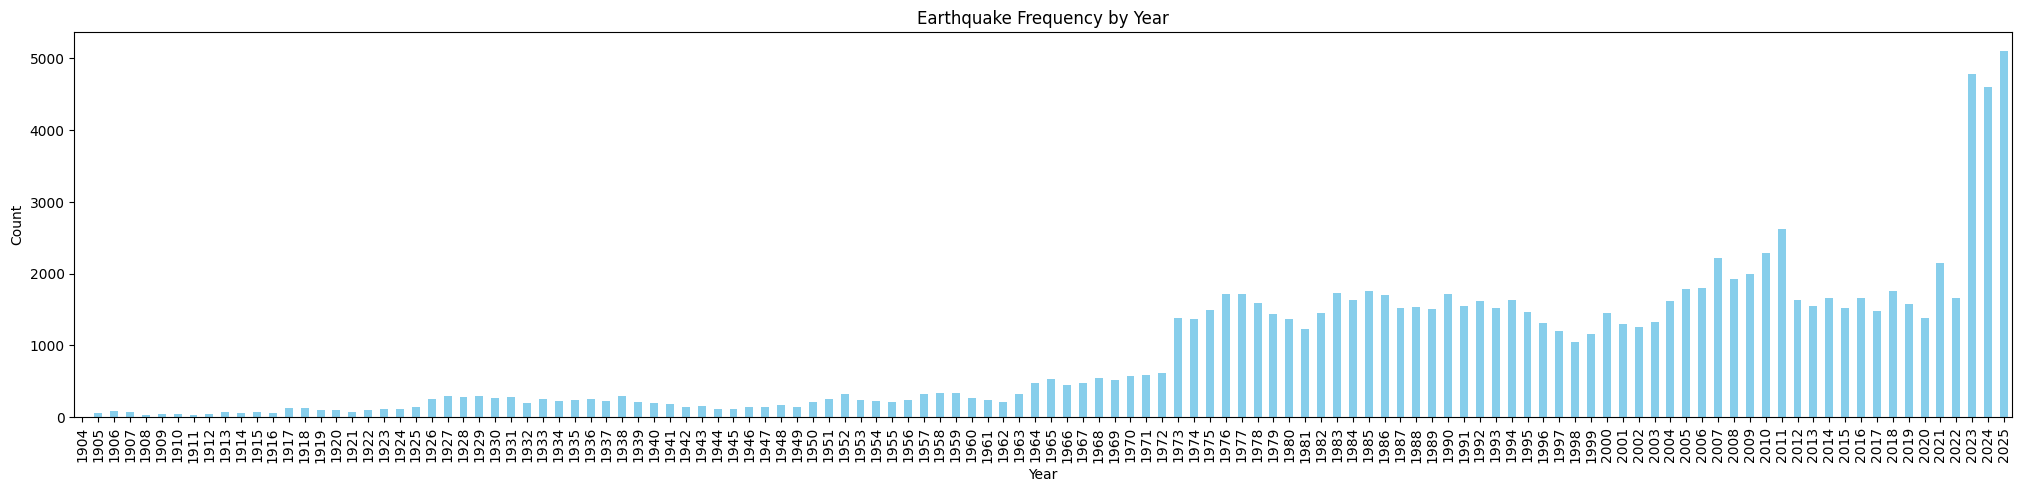

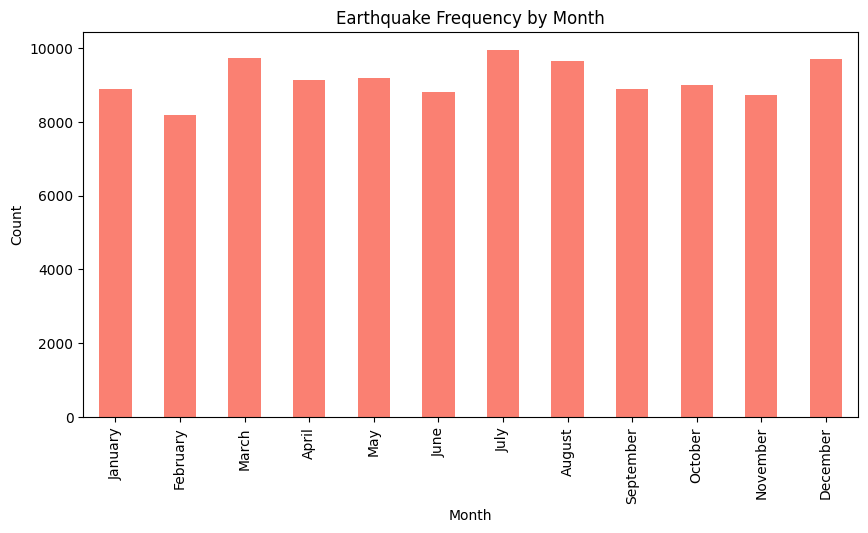

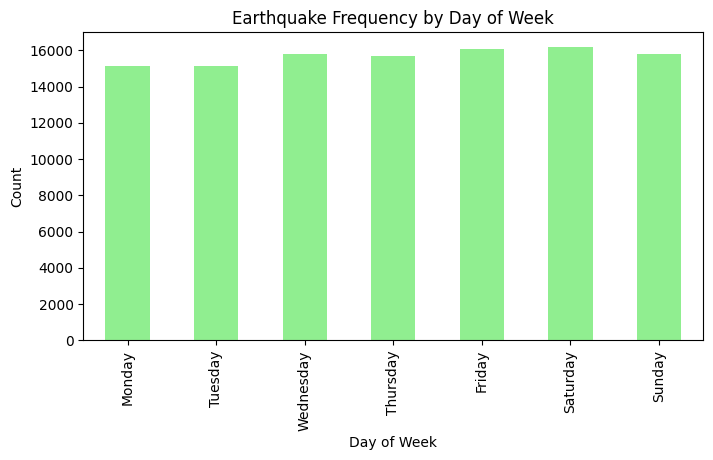

In [86]:
plt.figure(figsize=(25, 5))
yearly_counts.plot(kind='bar', color='skyblue')
plt.title('Earthquake Frequency by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
df['Month'].value_counts().reindex(month_order).plot(kind='bar', color='salmon')
plt.title('Earthquake Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 4))
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['DayOfWeek'].value_counts().reindex(weekday_order).plot(kind='bar', color='lightgreen')
plt.title('Earthquake Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

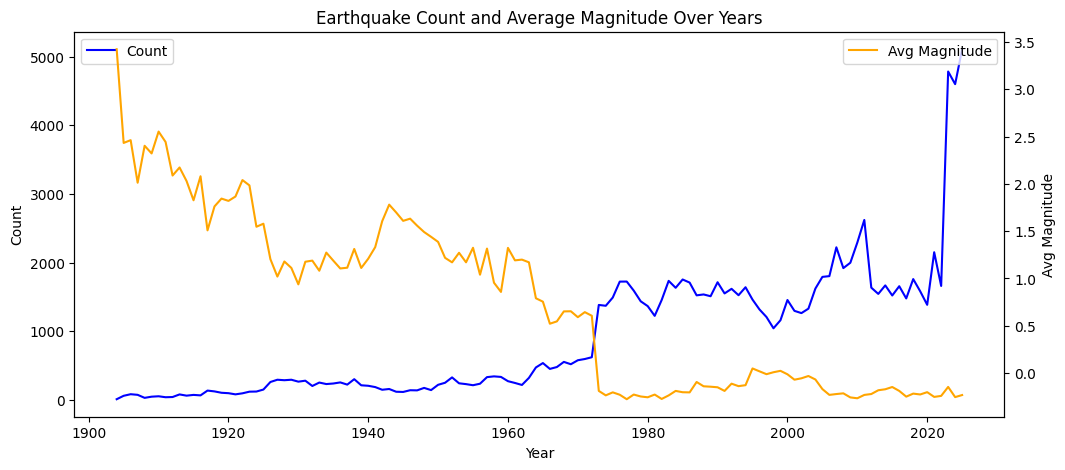

In [87]:
# Time series of earthquake counts and average magnitude by year
plt.figure(figsize=(12,5))
ax = df.groupby('Year').size().plot(label='Count', color='blue')
ax2 = ax.twinx()
df.groupby('Year')[magnitude_col].mean().plot(ax=ax2, color='orange', label='Avg Magnitude')
ax.set_ylabel('Count')
ax2.set_ylabel('Avg Magnitude')
ax.set_title('Earthquake Count and Average Magnitude Over Years')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

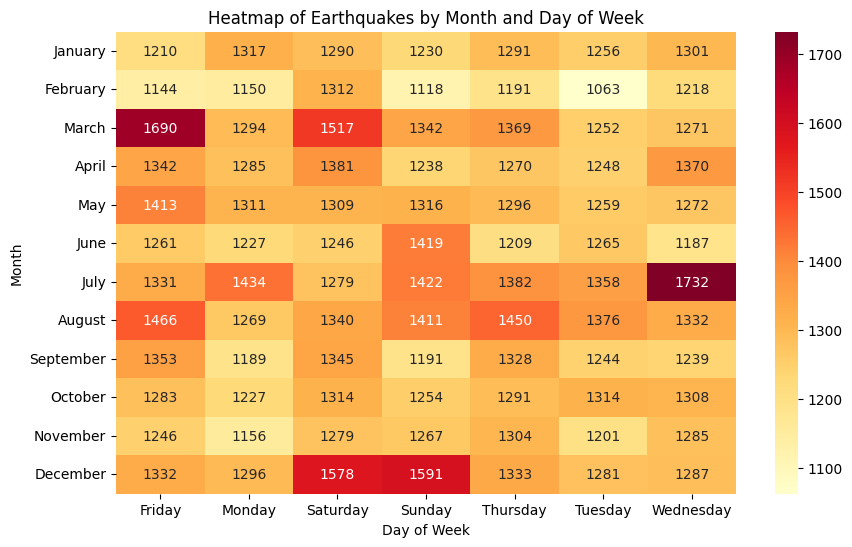

In [88]:
#  Heatmap of earthquakes by Month and DayOfWeek
heat_data = df.groupby(['Month','DayOfWeek']).size().unstack(fill_value=0)
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
heat_data = heat_data.reindex(month_order)

plt.figure(figsize=(10,6))
sns.heatmap(heat_data, cmap='YlOrRd', annot=True, fmt='d')
plt.title('Heatmap of Earthquakes by Month and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Month')
plt.show()

In [89]:
print("\nYearly Mean Magnitude:")
print(temporal_summary['Year'])

if damage_col:
    print("\nYearly Mean Damage Potential:")
    print(temporal_summary['Year_damage'])


Yearly Mean Magnitude:
Year
1904    3.424619
1905    2.433381
1906    2.462752
1907    2.012222
1908    2.403293
          ...   
2021   -0.253093
2022   -0.242423
2023   -0.147624
2024   -0.255237
2025   -0.233389
Name: mag, Length: 122, dtype: float64

Yearly Mean Damage Potential:
Year
1904    10.000000
1905    10.000000
1906     9.984457
1907     9.959922
1908    10.000000
          ...    
2021     9.571241
2022     9.445189
2023     9.393469
2024     9.361794
2025     9.619677
Name: damage_potential, Length: 122, dtype: float64


#### Task 2: Geographical Distribution Analysis
Explore spatial patterns of earthquake epicenters

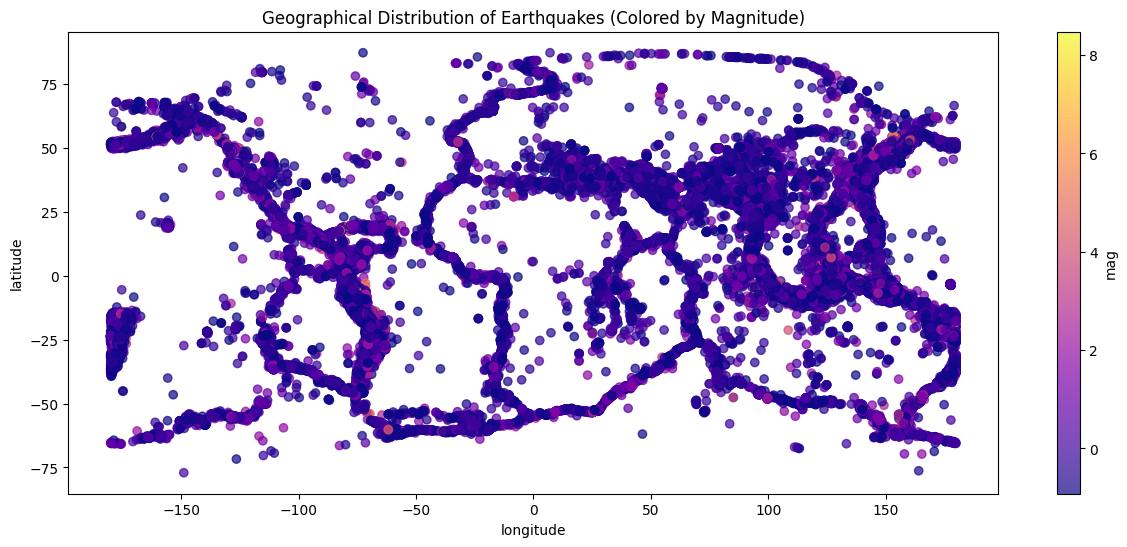

In [90]:
# Create scatter plot for latitude vs longitude colored by magnitude
plt.figure(figsize=(15, 6))
scatter = plt.scatter(
    df['longitude'], 
    df['latitude'], 
    c=df['mag'], 
    cmap='plasma', 
    alpha=0.7
)

plt.colorbar(scatter, label='mag')
plt.title('Geographical Distribution of Earthquakes (Colored by Magnitude)')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()

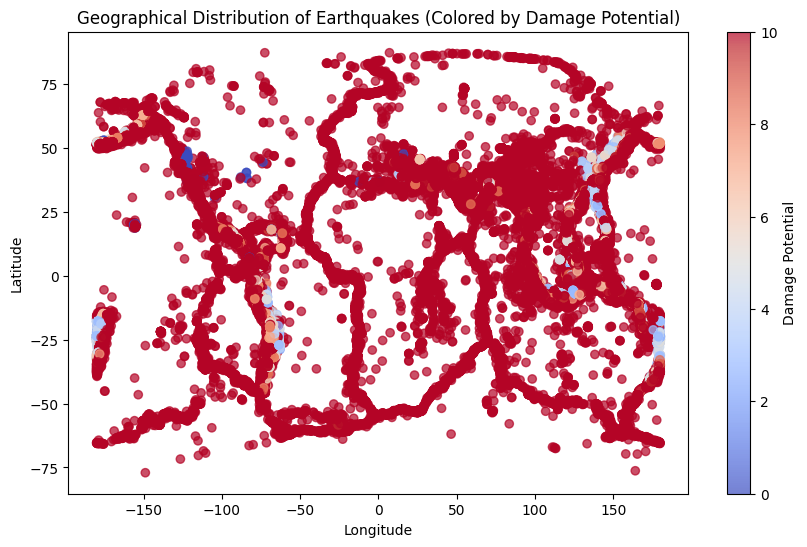

In [91]:
# Create scatter plot for latitude vs longitude colored by damage potential

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['longitude'], 
    df['latitude'], 
    c=df['damage_potential'], 
    cmap='coolwarm', 
    alpha=0.7
)

plt.colorbar(scatter, label='Damage Potential')
plt.title('Geographical Distribution of Earthquakes (Colored by Damage Potential)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

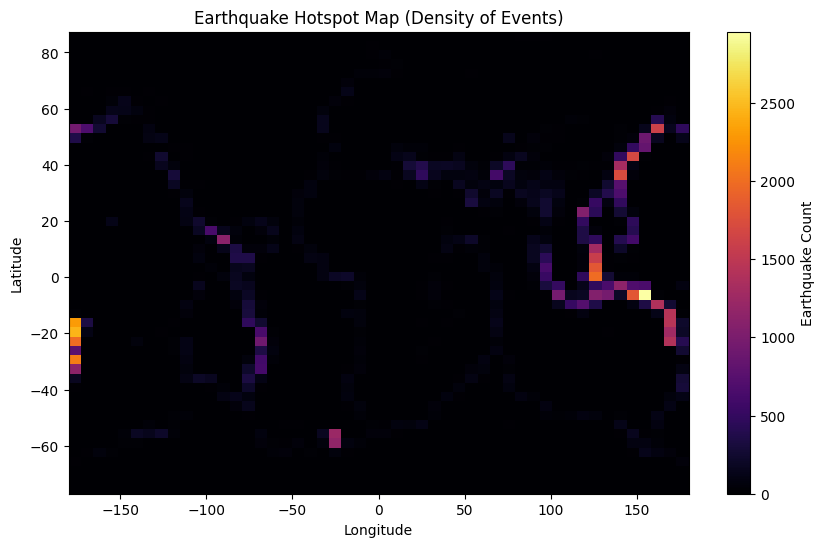

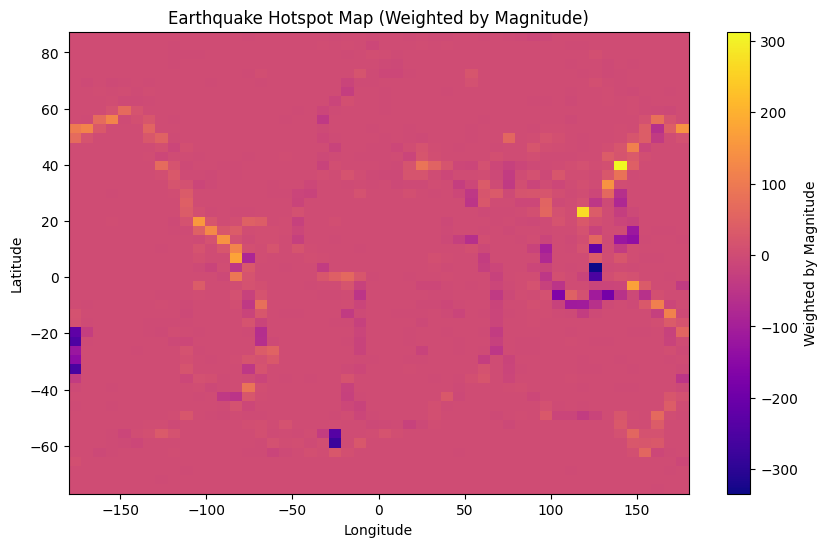

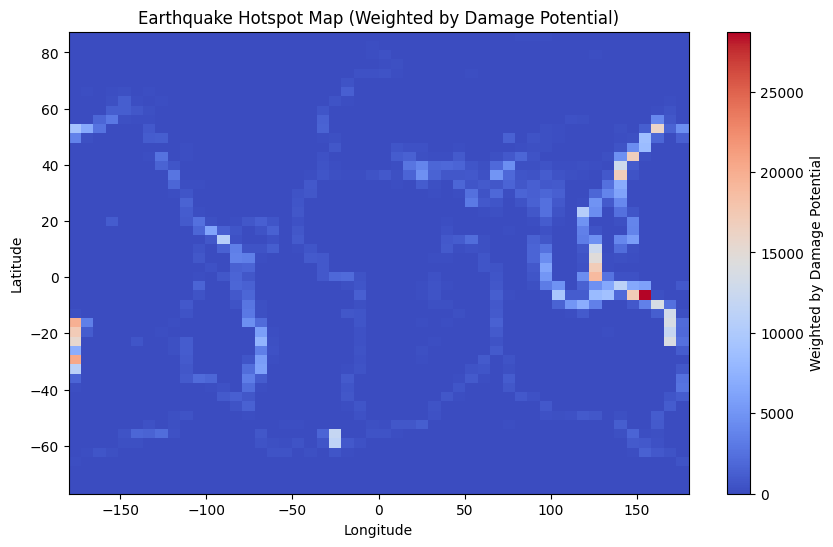

In [92]:
# 2D Histogram by Frequency

plt.figure(figsize=(10, 6))
plt.hist2d(
    df['longitude'], 
    df['latitude'], 
    bins=(50, 50),         # number of grid bins for density
    cmap='inferno'         # color map representing density
)
plt.colorbar(label='Earthquake Count')
plt.title('Earthquake Hotspot Map (Density of Events)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


# Weighted 2D Histogram by Magnitude

# This highlights areas with both high frequency AND higher magnitudes.
plt.figure(figsize=(10, 6))
plt.hist2d(
    df['longitude'], 
    df['latitude'], 
    bins=(50, 50),
    weights=df['mag'],  # weight each point by its magnitude
    cmap='plasma'
)
plt.colorbar(label='Weighted by Magnitude')
plt.title('Earthquake Hotspot Map (Weighted by Magnitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Weighted 2D Histogram by Damage Potential

# This highlights high-risk zones (high damage potential).
plt.figure(figsize=(10, 6))
plt.hist2d(
    df['longitude'], 
    df['latitude'], 
    bins=(50, 50),
    weights=df['damage_potential'],  # weight by damage potential
    cmap='coolwarm'
)
plt.colorbar(label='Weighted by Damage Potential')
plt.title('Earthquake Hotspot Map (Weighted by Damage Potential)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [93]:
#  Create Latitude and Longitude Bins

# Divide the globe (or dataset coverage) into evenly spaced bins
lat_bins = np.arange(df['latitude'].min(), df['latitude'].max(), 5)
lon_bins = np.arange(df['longitude'].min(), df['longitude'].max(), 5)

# Categorize each earthquake into a lat/lon region
df['Lat_Bin'] = pd.cut(df['latitude'], bins=lat_bins)
df['Lon_Bin'] = pd.cut(df['longitude'], bins=lon_bins)

#  Compute Summary Statistics for Each Region

region_summary = (
    df.groupby(['Lat_Bin', 'Lon_Bin'])
    .agg(
        Earthquake_Count=('mag', 'count'),
        Mean_Magnitude=('mag', 'mean'),
        Mean_Damage_Potential=('damage_potential', 'mean')
    )
    .reset_index()
)

# Display top 10 regions for preview
print(region_summary.head(10))


            Lat_Bin               Lon_Bin  Earthquake_Count  Mean_Magnitude  \
0  (-77.08, -72.08]  (-179.997, -174.997]                 0             NaN   
1  (-77.08, -72.08]  (-174.997, -169.997]                 0             NaN   
2  (-77.08, -72.08]  (-169.997, -164.997]                 0             NaN   
3  (-77.08, -72.08]  (-164.997, -159.997]                 0             NaN   
4  (-77.08, -72.08]  (-159.997, -154.997]                 0             NaN   
5  (-77.08, -72.08]  (-154.997, -149.997]                 0             NaN   
6  (-77.08, -72.08]  (-149.997, -144.997]                 0             NaN   
7  (-77.08, -72.08]  (-144.997, -139.997]                 0             NaN   
8  (-77.08, -72.08]  (-139.997, -134.997]                 0             NaN   
9  (-77.08, -72.08]  (-134.997, -129.997]                 0             NaN   

   Mean_Damage_Potential  
0                    NaN  
1                    NaN  
2                    NaN  
3                    N

C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20612\222508550.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Lat_Bin', 'Lon_Bin'])


C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20612\4036856205.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = region_summary.pivot_table(


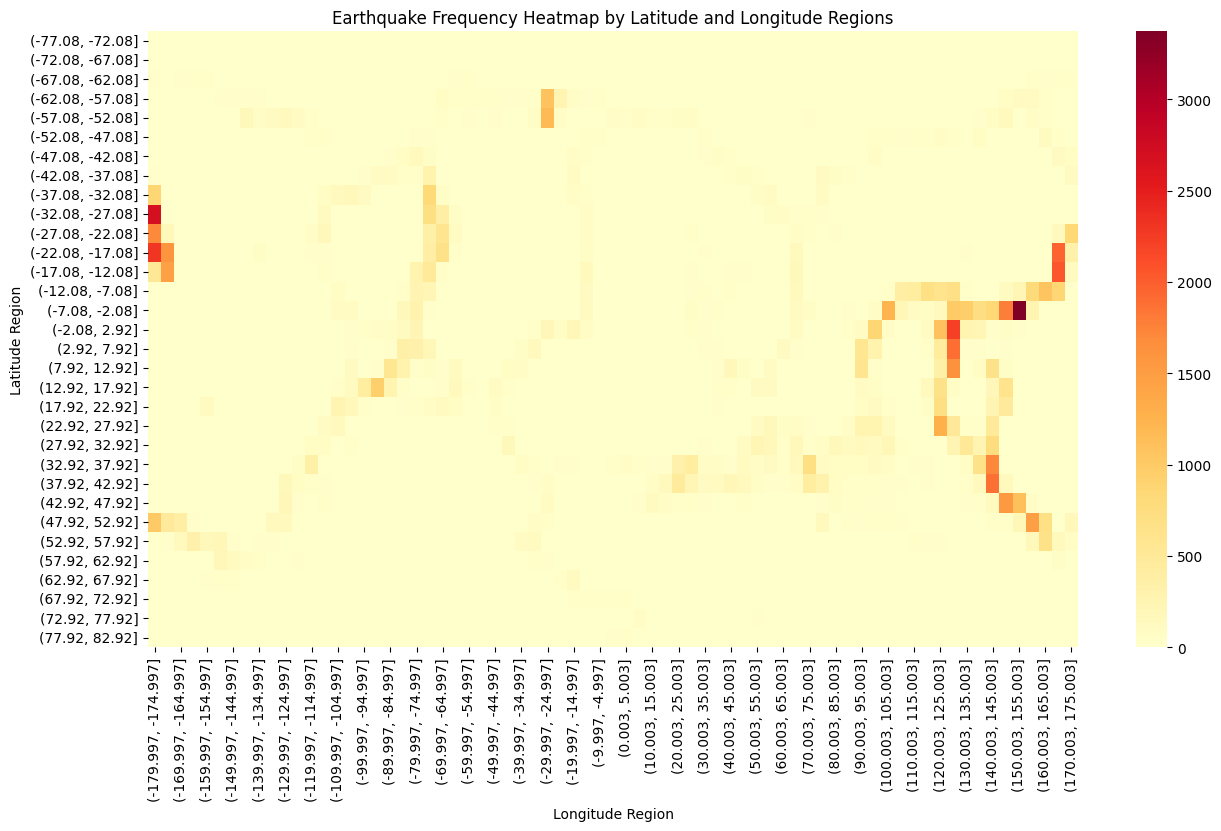

In [94]:
 # Visualize Earthquake Density by Region (Heatmap)

pivot_table = region_summary.pivot_table(
    index='Lat_Bin', columns='Lon_Bin', values='Earthquake_Count', fill_value=0
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, cmap='YlOrRd')
plt.title('Earthquake Frequency Heatmap by Latitude and Longitude Regions')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()

C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20612\3692579634.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mag = region_summary.pivot_table(


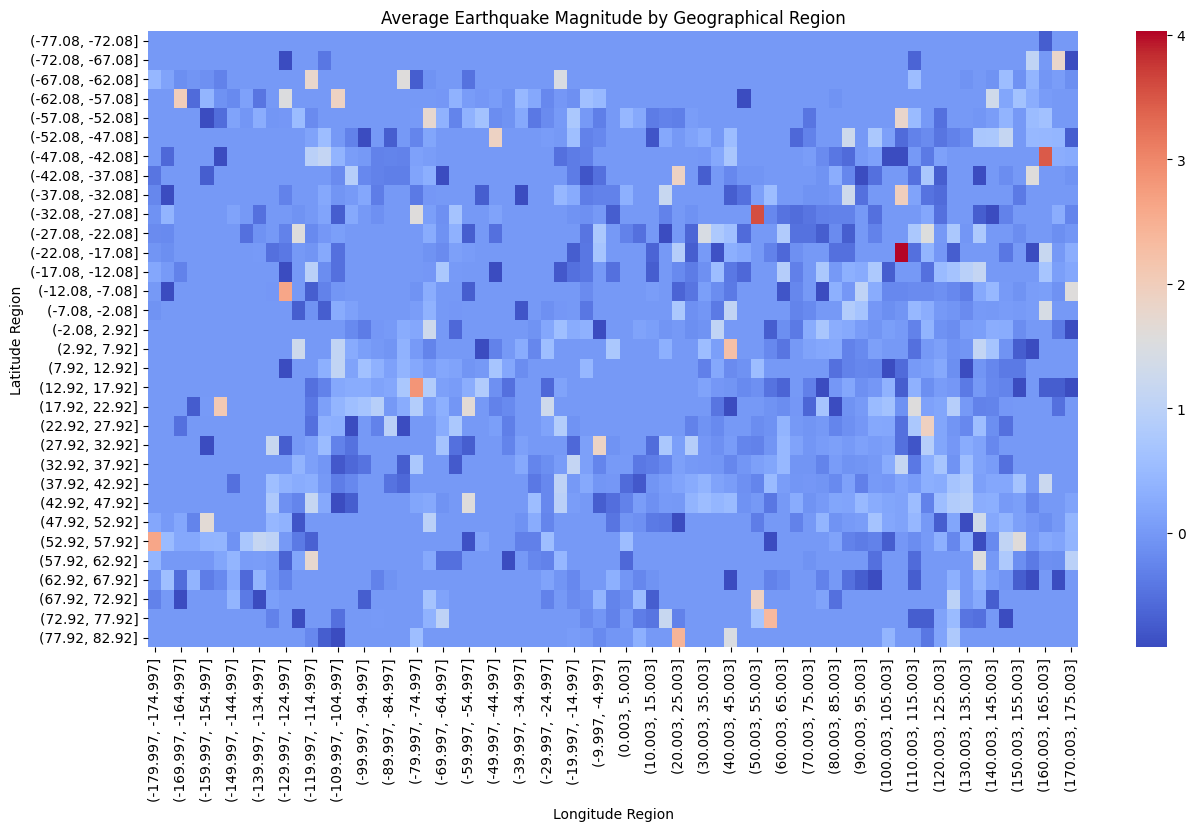

In [95]:
#  Visualize Average Magnitude by Region

pivot_mag = region_summary.pivot_table(
    index='Lat_Bin', columns='Lon_Bin', values='Mean_Magnitude', fill_value=0
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_mag, cmap='coolwarm')
plt.title('Average Earthquake Magnitude by Geographical Region')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()


C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20612\1483301182.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_damage = region_summary.pivot_table(


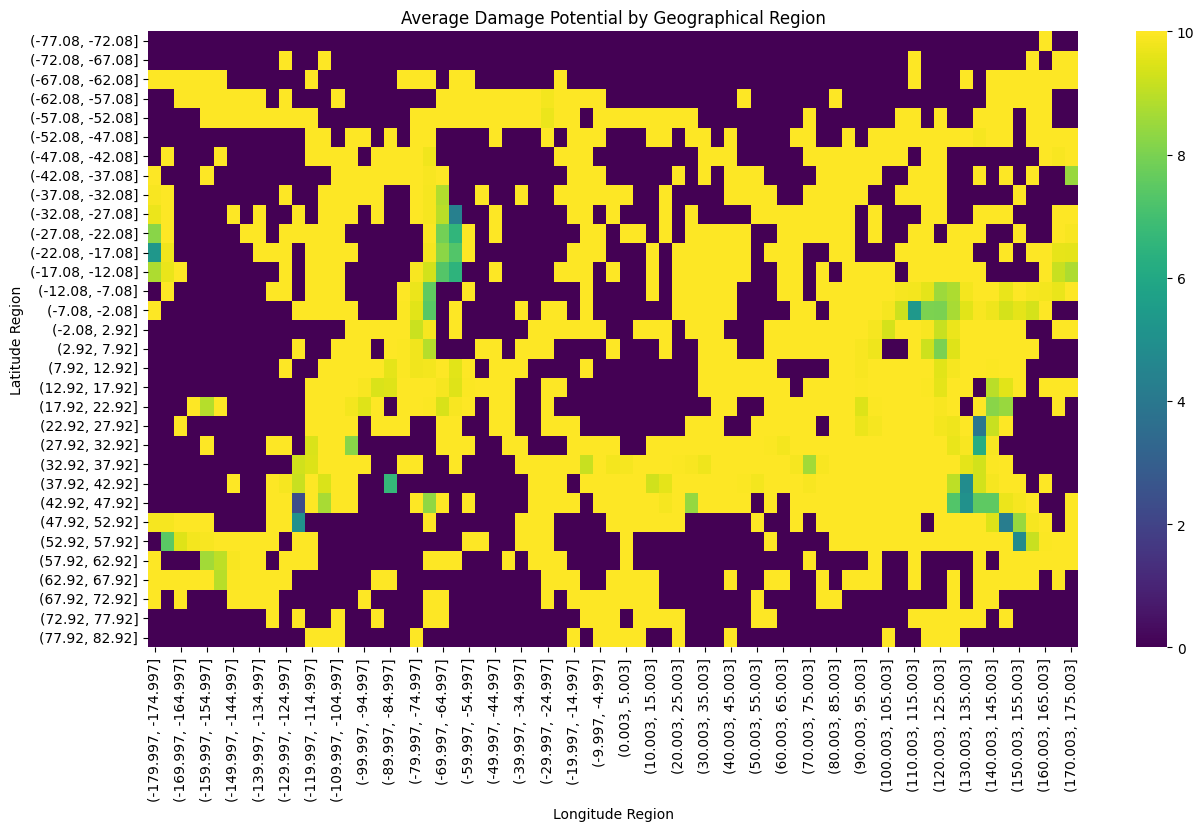

In [96]:
# Visualize Average Damage Potential by Region

pivot_damage = region_summary.pivot_table(
    index='Lat_Bin', columns='Lon_Bin', values='Mean_Damage_Potential', fill_value=0
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_damage, cmap='viridis')
plt.title('Average Damage Potential by Geographical Region')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()


Correlation Matrix:
                  latitude  longitude       mag  damage_potential
latitude          1.000000   0.213085  0.044229          0.098566
longitude         0.213085   1.000000 -0.002900          0.093421
mag               0.044229  -0.002900  1.000000          0.031456
damage_potential  0.098566   0.093421  0.031456          1.000000


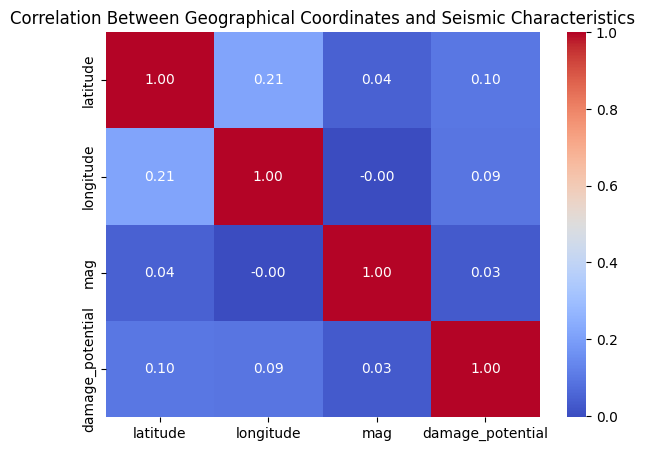

In [97]:
#  Compute Correlation Matrix

corr_matrix = df[['latitude', 'longitude', 'mag', 'damage_potential']].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)


#  Visualize Correlation Matrix (Heatmap)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Geographical Coordinates and Seismic Characteristics')
plt.show()

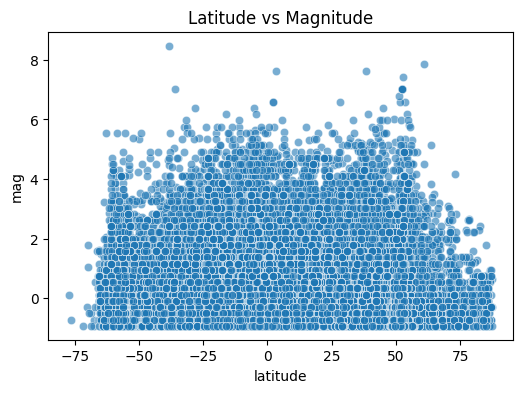

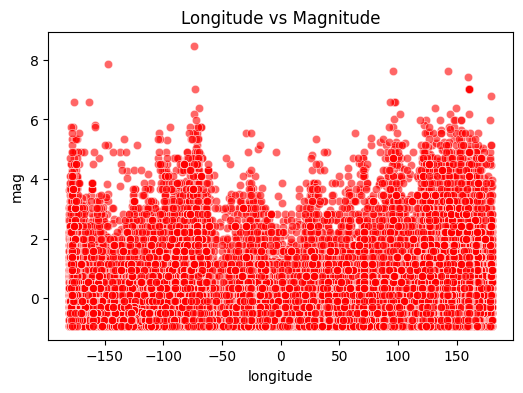

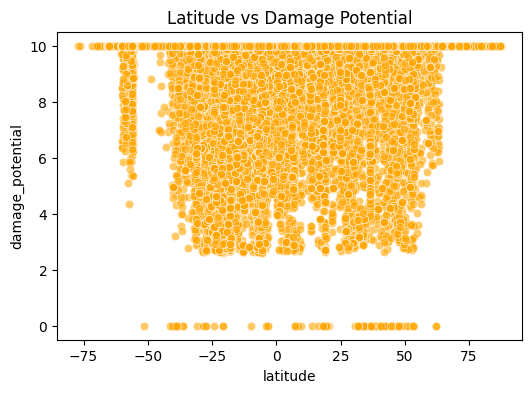

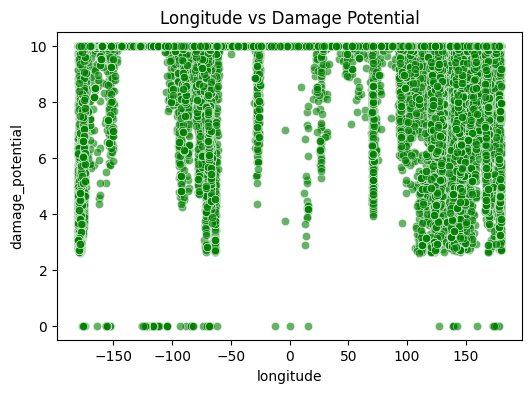

In [98]:
# Latitude vs Magnitude
plt.figure(figsize=(6, 4))
sns.scatterplot(x='latitude', y='mag', data=df, alpha=0.6)
plt.title('Latitude vs Magnitude')
plt.show()

# Longitude vs Magnitude
plt.figure(figsize=(6, 4))
sns.scatterplot(x='longitude', y='mag', data=df, alpha=0.6 , color="red")
plt.title('Longitude vs Magnitude')
plt.show()

# Latitude vs Damage Potential
plt.figure(figsize=(6, 4))
sns.scatterplot(x='latitude', y='damage_potential', data=df, alpha=0.6, color='orange')
plt.title('Latitude vs Damage Potential')
plt.show()

# Longitude vs Damage Potential
plt.figure(figsize=(6, 4))
sns.scatterplot(x='longitude', y='damage_potential', data=df, alpha=0.6, color='green')
plt.title('Longitude vs Damage Potential')
plt.show()

In [99]:
# Bin by Geographic Regions

lat_bins = np.arange(df['latitude'].min(), df['latitude'].max(), 5)
lon_bins = np.arange(df['longitude'].min(), df['longitude'].max(), 5)

df['Lat_Bin'] = pd.cut(df['latitude'], bins=lat_bins)
df['Lon_Bin'] = pd.cut(df['longitude'], bins=lon_bins)

 # Compute Average Damage Potential per Region

risk_summary = (
    df.groupby(['Lat_Bin', 'Lon_Bin'])
    .agg(
        Mean_Damage_Potential=('damage_potential', 'mean'),
        Mean_Magnitude=('mag', 'mean'),
        Event_Count=('damage_potential', 'count')
    )
    .reset_index()
)

print("Top 10 High-Risk Regions:")
print(risk_summary.sort_values(by='Mean_Damage_Potential', ascending=False).head(10))

Top 10 High-Risk Regions:
               Lat_Bin               Lon_Bin  Mean_Damage_Potential  \
212   (-67.08, -62.08]    (170.003, 175.003]                   10.0   
2262    (77.92, 82.92]    (125.003, 130.003]                   10.0   
68    (-77.08, -72.08]    (160.003, 165.003]                   10.0   
81    (-72.08, -67.08]  (-129.997, -124.997]                   10.0   
84    (-72.08, -67.08]  (-114.997, -109.997]                   10.0   
129   (-72.08, -67.08]    (110.003, 115.003]                   10.0   
138   (-72.08, -67.08]    (155.003, 160.003]                   10.0   
140   (-72.08, -67.08]    (165.003, 170.003]                   10.0   
141   (-72.08, -67.08]    (170.003, 175.003]                   10.0   
142   (-67.08, -62.08]  (-179.997, -174.997]                   10.0   

      Mean_Magnitude  Event_Count  
212        -0.129226           30  
2262        0.787469            6  
68         -0.712513            1  
81         -0.921328            1  
84         -

C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20612\2569605431.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Lat_Bin', 'Lon_Bin'])


C:\Users\divyanshu\AppData\Local\Temp\ipykernel_20612\1076084653.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_risk = risk_summary.pivot_table(


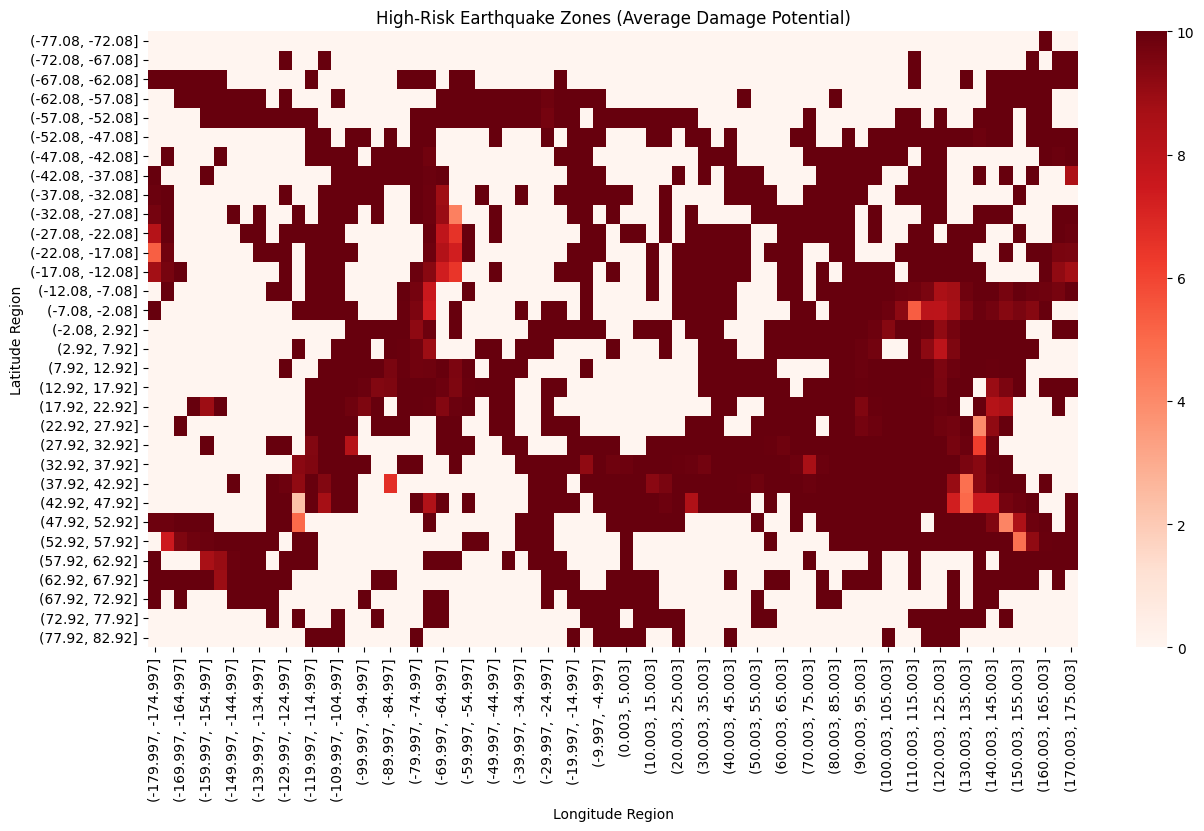

In [100]:
# Heatmap: Average Damage Potential by Region

pivot_risk = risk_summary.pivot_table(
    index='Lat_Bin', columns='Lon_Bin', values='Mean_Damage_Potential', fill_value=0
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_risk, cmap='Reds')
plt.title('High-Risk Earthquake Zones (Average Damage Potential)')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()

#### Task 3: Magnitude and Damage Potential Relationship
 Analyze the relationship between earthquake magnitude and damage potential.